## Path configuration

In [1]:
from pathlib import Path
import os

PROJECT_NAME = "MALDIAlign"

cwd = Path().resolve()

# Walk upwards until we find the project folder
target = None
for parent in [cwd] + list(cwd.parents):
    if parent.name == PROJECT_NAME:
        target = parent
        break

# If the project folder is found and we are not already there, then change cwd
if target is not None and target != cwd:
    os.chdir(target)

print("Working directory:", os.getcwd())

Working directory: /export/usuarios01/agnavarr/MALDIAlign


## Imports

In [67]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# utils
from utils.load_config import load_config
from utils.load_data import load_pkl
from utils.metrics import *

# tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

## Data loading

In [14]:
cfg = load_config()
driams_pkl = cfg["data"]["DRIAMS_REDUCED_PKL"]

In [15]:
driams = load_pkl(driams_pkl)

In [16]:
data, label, meta = driams["data"], driams["label"], driams["meta"]

In [17]:
meta = pd.DataFrame.from_records(list(meta))

In [18]:
# Filter the data by hospital
filtered_data = {}
for hosp in meta["hospital"].unique():
    idx = np.where(meta["hospital"].values == hosp)[0]
    filtered_data[hosp] = {
        "data": data[idx],
        "label": label[idx],
        "meta": meta.iloc[idx]
    }

In [19]:
species, counts = np.unique(filtered_data["DRIAMS_A"]["label"], return_counts=True)
for sp, n in zip(species, counts):
    print(f"{sp}: {n}")

Enterobacter_cloacae_complex: 2573
Enterococcus_Faecium: 1800
Escherichia_Coli: 7381
Klebsiella_Pneumoniae: 4083
Pseudomonas_Aeruginosa: 4908
Staphylococcus_Aureus: 7065


In [20]:
# Declare the datasets
dataA, labelA, metaA = filtered_data["DRIAMS_A"]["data"], filtered_data["DRIAMS_A"]["label"], filtered_data["DRIAMS_A"]["meta"]
dataB, labelB, metaB = filtered_data["DRIAMS_B"]["data"], filtered_data["DRIAMS_B"]["label"], filtered_data["DRIAMS_B"]["meta"]
dataC, labelC, metaC = filtered_data["DRIAMS_C"]["data"], filtered_data["DRIAMS_C"]["label"], filtered_data["DRIAMS_C"]["meta"]
dataD, labelD, metaD = filtered_data["DRIAMS_D"]["data"], filtered_data["DRIAMS_D"]["label"], filtered_data["DRIAMS_D"]["meta"]

In [21]:
dataA.shape

(27810, 6000)

In [22]:
dataD.shape

(7308, 6000)

## Models

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    dataA,
    labelA,
    test_size=0.2,
    stratify=labelA,
    shuffle=True,
    random_state=42
)

In [24]:
# Scale the data
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#with open("models/baselines/trained_models/scaler_A.pkl", "wb") as file:
#    pickle.dump(scaler, file)

### Logistic Regression

#### PCA for LR

In [60]:
# Apply PCA to reduce the dimensionality (there are 6000 features)
my_pca = PCA().fit(X_train_scaled)

In [61]:
# explained_variance_ returns the amount of variance explained by each of the selected components
# explained_variance_ratio_ returnd the percentage of variance explained by each of the selected components
cumulative_explained_var = np.cumsum(my_pca.explained_variance_)
cumulative_explained_var_ratio = np.cumsum(my_pca.explained_variance_ratio_)

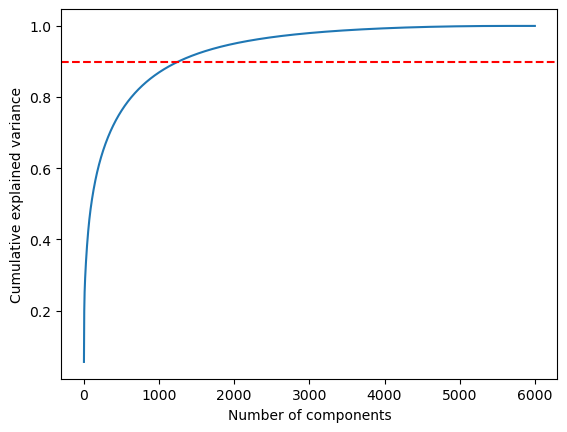

In [62]:
plt.plot(np.arange(1, len(cumulative_explained_var_ratio)+1), cumulative_explained_var_ratio)
plt.axhline(0.9, color='r', linestyle='--')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.show()

In [63]:
n_components = np.argmax(cumulative_explained_var_ratio >= 0.70) + 1
print(f"Number of components explaining 70% variance: {n_components}")

Number of components explaining 70% variance: 347


#### Train

In [28]:
pca = PCA(n_components=300, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [ ]:
#with open("models/baselines/trained_models/pca_A.pkl", "wb") as file:
#    pickle.dump(pca, file)

In [30]:
lr_final = LogisticRegression(
    penalty="l2",
    solver="saga",
    C=1, 
    class_weight="balanced",           
    max_iter=2000,
    n_jobs=-1,
    random_state=42
)

lr_final.fit(X_train_pca, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'saga'
,max_iter,2000
,multi_class,'deprecated'


In [ ]:
#with open("models/baselines/trained_models//lr_baseline.pkl", "wb") as f:
#    pickle.dump(lr_final, f)

#### Test

In [33]:
X_B_scaled = scaler.transform(dataB)
X_B_pca = pca.transform(X_B_scaled)

X_C_scaled = scaler.transform(dataC)
X_C_pca = pca.transform(X_C_scaled)

X_D_scaled = scaler.transform(dataD)
X_D_pca = pca.transform(X_D_scaled)

In [68]:
metricsA = metrics_report(X_test_pca, y_test, lr_final, "DRIAMS-A")
metricsB = metrics_report(X_B_pca, labelB, lr_final, "DRIAMS-B")
metricsC = metrics_report(X_C_pca, labelC, lr_final, "DRIAMS-C")
metricsD = metrics_report(X_D_pca, labelD, lr_final, "DRIAMS-D")

Printing metrics for Domain: DRIAMS-A
Balanced Accuracy: 0.9983120328906883
F1 Macro: 0.9982057174738607
Recall Macro: 0.9983120328906883
Specificity Macro: 0.999673299553742


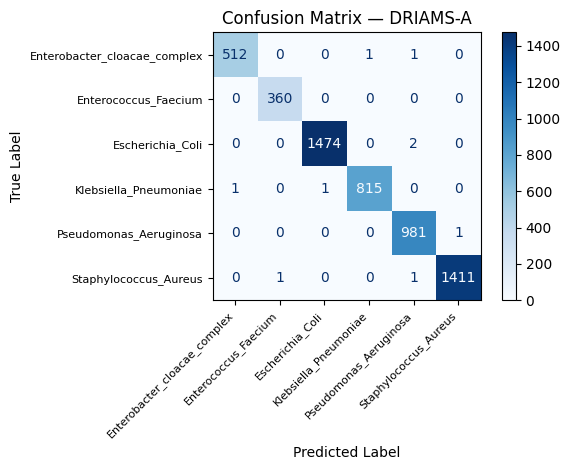

In [69]:
print_metrics(metricsA)

Printing metrics for Domain: DRIAMS-B
Balanced Accuracy: 0.9974865359996468
F1 Macro: 0.9982006886393869
Recall Macro: 0.9974865359996468
Specificity Macro: 0.9997618428924028


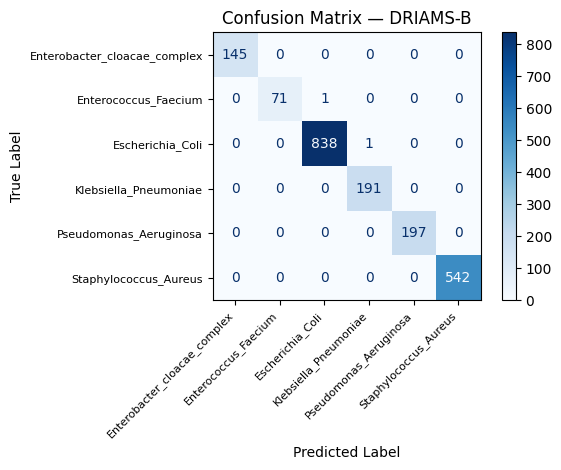

In [36]:
print_metrics(metricsB)

Printing metrics for Domain: DRIAMS-C
Balanced Accuracy: 0.9946664732636278
F1 Macro: 0.9957722260196981
Recall Macro: 0.9946664732636278
Specificity Macro: 0.9993636430282736


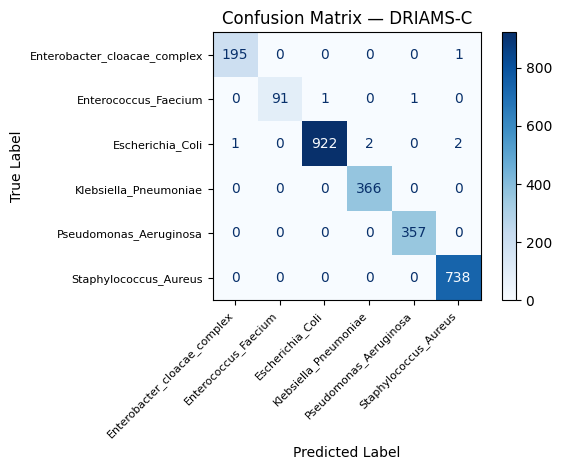

In [37]:
print_metrics(metricsC)

Printing metrics for Domain: DRIAMS-D
Balanced Accuracy: 0.9261179063282691
F1 Macro: 0.8971120149123308
Recall Macro: 0.9261179063282691
Specificity Macro: 0.9844270275448559


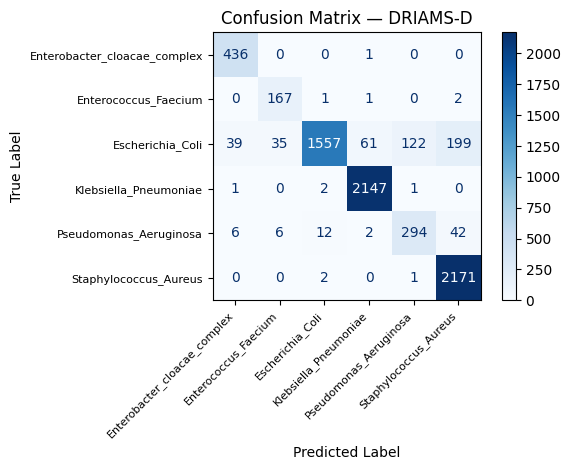

In [54]:
print_metrics(metricsD)

### RF

#### Train

In [39]:
rf_final = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)

rf_final.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
#with open("models/baselines/trained_models/rf_baseline.pkl", "wb") as f:
#    pickle.dump(rf_final, f)

#### Test

In [42]:
metricsA = metrics_report(X_test, y_test, rf_final, "DRIAMS-A")
metricsB = metrics_report(dataB, labelB, rf_final, "DRIAMS-B")
metricsC = metrics_report(dataC, labelC, rf_final, "DRIAMS-C")
metricsD = metrics_report(dataD, labelD, rf_final, "DRIAMS-D")

Printing metrics for Domain: DRIAMS-A
Balanced Accuracy: 0.9980799400708217
F1 Macro: 0.9984261966530027
Recall Macro: 0.9980799400708217
Specificity Macro: 0.9996975652008725


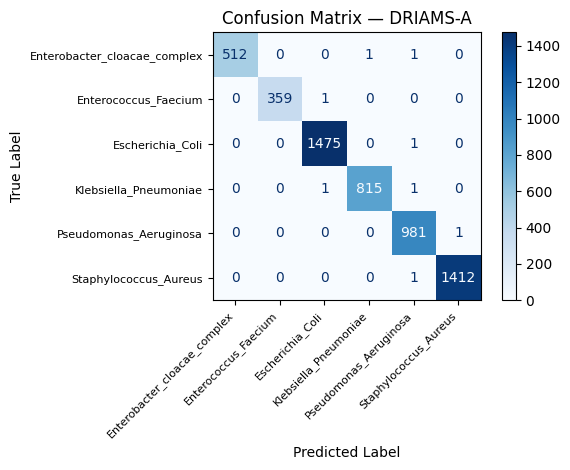

In [43]:
print_metrics(metricsA)

Printing metrics for Domain: DRIAMS-B
Balanced Accuracy: 1.0
F1 Macro: 1.0
Recall Macro: 1.0
Specificity Macro: 1.0


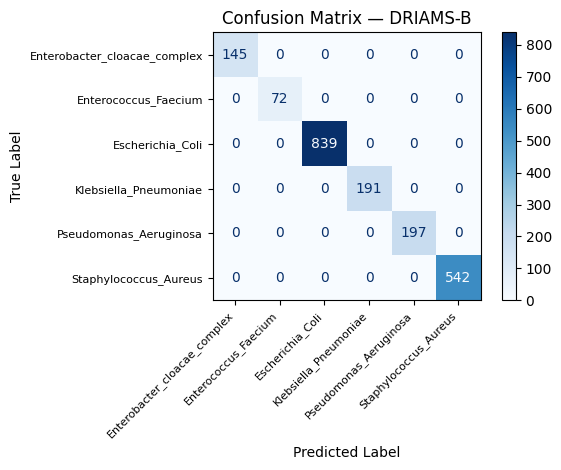

In [44]:
print_metrics(metricsB)

Printing metrics for Domain: DRIAMS-C
Balanced Accuracy: 0.9965425888785573
F1 Macro: 0.9976266303511347
Recall Macro: 0.9965425888785573
Specificity Macro: 0.9995657748098618


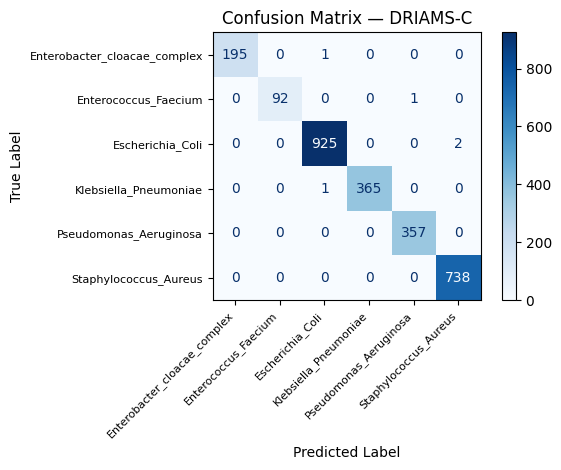

In [45]:
print_metrics(metricsC)

Printing metrics for Domain: DRIAMS-D
Balanced Accuracy: 0.919860822457494
F1 Macro: 0.9035521522681645
Recall Macro: 0.919860822457494
Specificity Macro: 0.9808204355689196


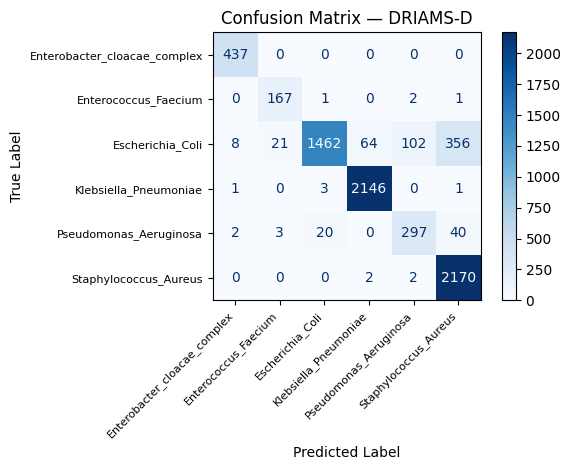

In [46]:
print_metrics(metricsD)

### SVM-Linear

#### Train

In [47]:
svm_final = LinearSVC(
    class_weight='balanced', 
    C=0.1,
    random_state=42)

svm_final.fit(X_train_scaled, y_train)

/export/usuarios01/agnavarr/MALDIAlign/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,0.1
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,42


In [ ]:
#with open("models/baselines/trained_models/svm_baseline.pkl", "wb") as f:
#    pickle.dump(svm_final, f)

#### Test

In [75]:
metricsA = metrics_report(X_test_scaled, y_test, svm_final, "DRIAMS-A")
metricsB = metrics_report(X_B_scaled, labelB, svm_final, "DRIAMS-B")
metricsC = metrics_report(X_C_scaled, labelC, svm_final, "DRIAMS-C")
metricsD = metrics_report(X_D_scaled, labelD, svm_final, "DRIAMS-D")

Printing metrics for Domain: DRIAMS-A
Balanced Accuracy: 0.9976007071869271
F1 Macro: 0.9976670754854107
Recall Macro: 0.9976007071869271
Specificity Macro: 0.9995588867542877


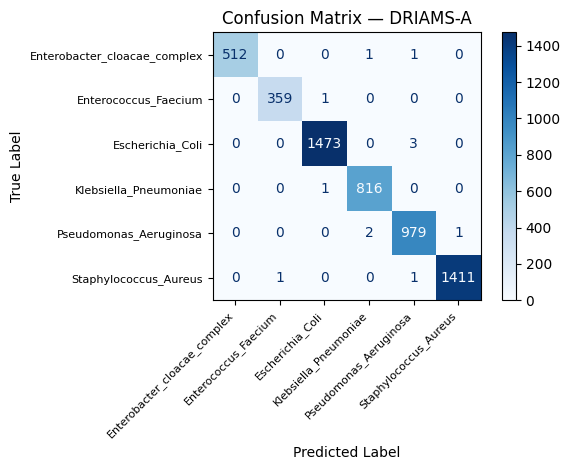

In [76]:
print_metrics(metricsA)

Printing metrics for Domain: DRIAMS-B
Balanced Accuracy: 0.9974865359996468
F1 Macro: 0.9982006886393869
Recall Macro: 0.9974865359996468
Specificity Macro: 0.9997618428924028


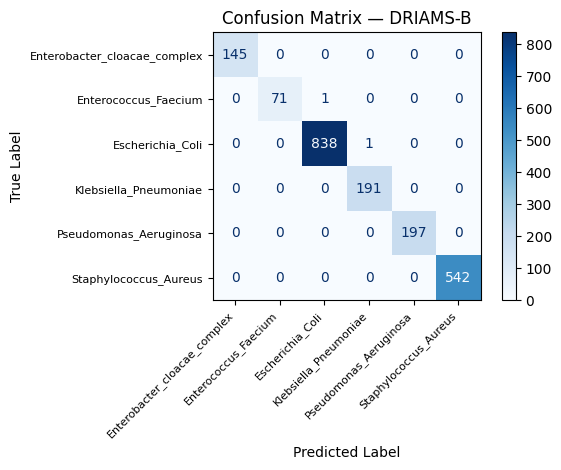

In [77]:
print_metrics(metricsB)

Printing metrics for Domain: DRIAMS-C
Balanced Accuracy: 0.997033346130757
F1 Macro: 0.9971681977784778
Recall Macro: 0.997033346130757
Specificity Macro: 0.9995451158545211


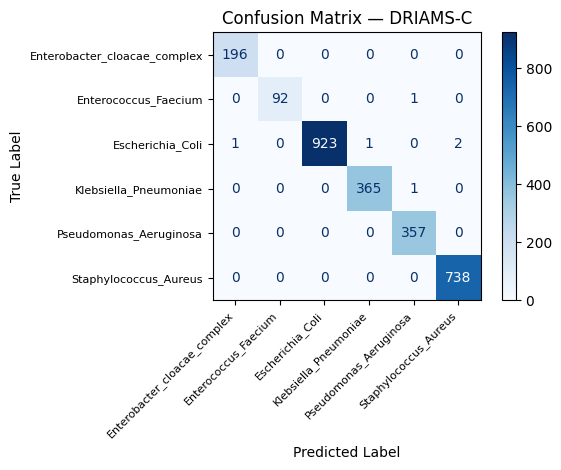

In [78]:
print_metrics(metricsC)

Printing metrics for Domain: DRIAMS-D
Balanced Accuracy: 0.9261179063282691
F1 Macro: 0.8971120149123308
Recall Macro: 0.9261179063282691
Specificity Macro: 0.9844270275448559


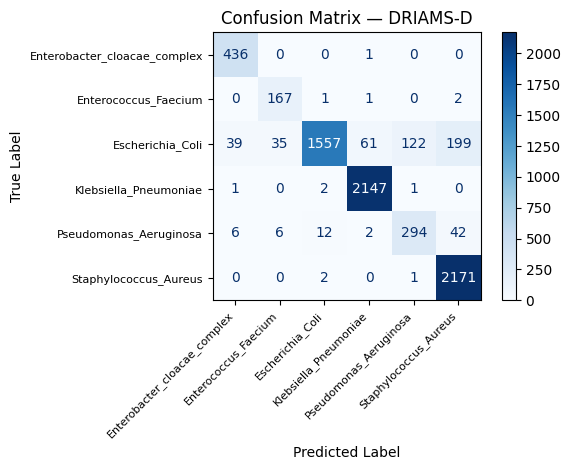

In [79]:
print_metrics(metricsD)